In [1]:
import os
import pickle
import pathlib

import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
from matplotlib import gridspec
import seaborn as sns
import pandas as pd
import pingouin as pg

import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u
import TwoPUtils as tpu

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice


plt.rcParams['pdf.fonttype']=42
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
figdir = pathlib.Path('/mnt/BigDisk/fig_scratch/stx3/figS4_running')
figdir.mkdir(exist_ok=True, parents=True)

In [3]:


rows = []
x = np.arange(-10,3)
for (cond, mice) in zip(('ctrl', 'ko', 'sparse'), (ctrl_mice, ko_mice, sparse_mice)):
    for day in range(6):
        
        print(day)
        for mouse in mice:

            if mouse == 'SparseKO_09' and day==2:
                continue
            print(mouse)
            sess = stx.utilities.load_vr_day(mouse, day,verbose = False, pkldir = '/mnt/BigDisk/YMaze_VR_Pkls/', trial_mat_keys=['licks', 
                                                                                                                                'licks_sum', 
                                                                                                                                'nonconsum_licks', 
                                                                                                                                'consum_licks', 
                                                                                                                                'licks_rate', 'speed'])
            #
            for ttype in ('fam', 'nov'):
                
                if ttype == 'nov':
                    trial_mask = sess.trial_info["LR"] == sess.novel_arm
                  
                else:
                    trial_mask = sess.trial_info["LR"] != sess.novel_arm
               

                
                speed = sess.trial_matrices['speed'][trial_mask,:]
                
                rows.append({'cond': cond,
                            'mouse': mouse,
                            'day': day,
                            'ttype': ttype,
                            'speed': np.nanmean(sess.trial_matrices['speed'][trial_mask,:].ravel()),
                            })
df = pd.DataFrame(rows)
                    
                

0
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
1
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
2
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
3
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
4
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
5
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
0
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
1
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
2
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
3
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
4
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
5
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
0
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09
1
SparseKO_02


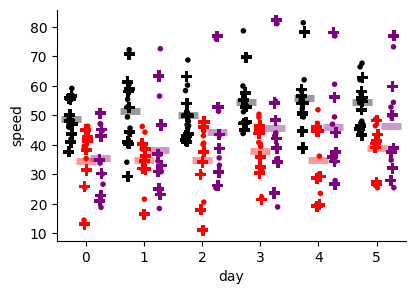

In [4]:
fig,ax = plt.subplots( figsize=[4.5,3], sharey = True)
for i, nov in enumerate(('fam','nov')):
    if nov == 'nov':
        marker = 'P'
        s = 8
    else:
        marker = '.'
        s = 8
    sns.stripplot(data=df.loc[df['ttype']==nov,:],
                x='day',
                y='speed',
                hue='cond', 
                hue_order=('ctrl', 'ko','sparse'), 
                palette=['black', 'red','purple'],
                dodge=True,
                ax=ax, marker = marker, s=s,
                legend=False)
    


sns.pointplot(data=df,
            x='day',
            y='speed',
            errorbar=None,
            hue='cond',
            hue_order = ['ctrl', 'ko', 'sparse'],
            dodge = .5,
            palette = ['black', 'red', 'purple'],
            ax=ax,
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
            )
    # ax[i].set_title(nov)

# for a in ax:
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('speed')


fig.savefig(figdir / "running_summary.pdf")


In [5]:
import statsmodels.formula.api as smf

df['rank_speed'] = df['speed'].rank()
mdl = smf.mixedlm('rank_speed ~ C(ttype) + C(day) + C(cond)', df, groups=df['mouse'])
mdl_result = mdl.fit()

mdl_result.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
              Mixed Linear Model Regression Results
=================================================================
Model:               MixedLM    Dependent Variable:    rank_speed
No. Observations:    274        Method:                REML      
No. Groups:          23         Scale:                 1295.2702 
Min. group size:     10         Log-Likelihood:        -1376.7254
Max. group size:     12         Converged:             Yes       
Mean group size:     11.9                                        
-----------------------------------------------------------------
                   Coef.   Std.Err.   z    P>|z|  [0.025   0.975]
-----------------------------------------------------------------
Intercept          177.862   19.414  9.161 0.000  139.810 215.913
C(ttype)[T.nov]    -13.467    4.348 -3.097 0.002  -21.990  -4.944
C(day)[T.1]          5.739    7.504  0.765 0.444   -8.969  20.447
C(day)[T.2]         13.947    7.605  1.834 0.067   -0.959  28.853
C(day)[T.3]         33.217    7.504  4.426 0.000   18.509  47.926
C(day)[T.4]         32.065    7.504  4.273 0.000   17.357  46.774
C(day)[T.5]         39.152    7.504  5.217 0.000   24.444  53.861
C(cond)[T.ko]     -106.136   28.231 -3.760 0.000 -161.468 -50.805
C(cond)[T.sparse]  -73.427   28.239 -2.600 0.009 -128.774 -18.080
Group Var         3030.165   28.677                              
=================================================================

"""

In [6]:
mdl_result.wald_test_terms()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                             chi2                 P>chi2  df constraint
Intercept   [[83.93114205813792]]  5.123112795452496e-20              1
C(ttype)    [[9.591395280579935]]  0.0019549133455305247              1
C(day)      [[46.94565965728864]]  5.828247507803449e-09              5
C(cond)    [[15.264305526075525]]  0.0004846164701591446              2

In [8]:
mdl_result.wald_test('C(cond)[T.sparse]=0')

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.ContrastResults'>
<Wald test (chi2): statistic=[[6.7610928]], p-value=0.00931666878570179, df_denom=1>

In [9]:
mdl_result.wald_test('C(cond)[T.ko]=0')

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.ContrastResults'>
<Wald test (chi2): statistic=[[14.13450612]], p-value=0.00017019302587551835, df_denom=1>

In [10]:
mdl_result.wald_test('C(cond)[T.sparse]=C(cond)[T.ko]')

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.ContrastResults'>
<Wald test (chi2): statistic=[[1.19265977]], p-value=0.27479370463642633, df_denom=1>

Shapiro-Wilk: W=0.991, p=0.11
D'Agostino: χ²=2.593, p=0.273


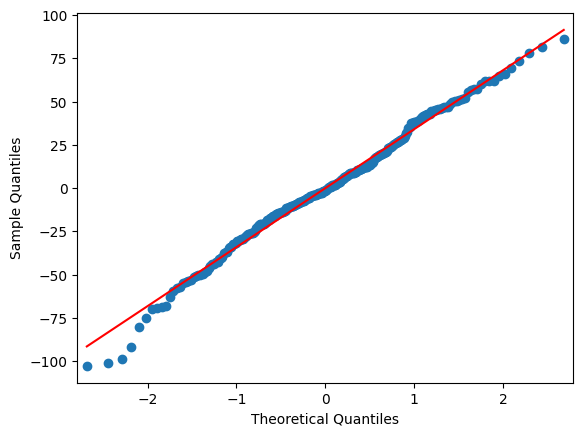

In [7]:
import statsmodels.api as sm
from scipy.stats import shapiro, normaltest, anderson
fig = sm.qqplot(mdl_result.resid, line ='s')

# Shapiro-Wilk test (good for small–moderate n)
shapiro_test = shapiro(mdl_result.resid)
print(f"Shapiro-Wilk: W={shapiro_test.statistic:.3f}, p={shapiro_test.pvalue:.3g}")

# D’Agostino and Pearson omnibus test (good for larger n)
dagostino_test = normaltest(mdl_result.resid)
print(f"D'Agostino: χ²={dagostino_test.statistic:.3f}, p={dagostino_test.pvalue:.3g}")

In [11]:
pg.pairwise_tests(data = df, dv='rank_speed', within='day', between='cond', subject='mouse', 
                  parametric=False, padjust='holm')

,Contrast,day,A,B,Paired,Parametric,U-val,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,day,-,0,1,True,False,NaN,110.0,two-sided,0.610152,1.000000,holm,-0.063346
1,day,-,0,2,True,False,NaN,92.5,two-sided,0.276740,1.000000,holm,-0.159502
2,day,-,0,3,True,False,NaN,53.0,two-sided,0.015583,0.178581,holm,-0.410041
3,day,-,0,4,True,False,NaN,49.0,two-sided,0.010324,0.134218,holm,-0.376928
4,day,-,0,5,True,False,NaN,35.0,two-sided,0.001918,0.026856,holm,-0.455134
5,day,-,1,2,True,False,NaN,105.0,two-sided,0.495294,1.000000,holm,-0.080940
6,day,-,1,3,True,False,NaN,52.5,two-sided,0.017015,0.178581,holm,-0.306470
7,day,-,1,4,True,False,NaN,66.0,two-sided,0.088545,0.619813,holm,-0.282665
8,day,-,1,5,True,False,NaN,61.0,two-sided,0.034823,0.313410,holm,-0.346295
9,day,-,2,3,True,False,NaN,27.0,two-sided,0.001308,0.019614,holm,-0.242170


In [ ]:

# sess = u.load_single_day(sparse_mice[0],5)

{'date': '04_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'ravel_ind': 5}


In [43]:
row = []
for cond, mice in zip(('ctrl', 'ko', 'sparse'), (ctrl_mice, ko_mice, sparse_mice)):
    for day in range(6):
        for mouse in mice:
            if mouse == 'SparseKO_09' and day ==2:
                continue
            sess = u.load_vr_day(mouse, day, pkldir = '/mnt/BigDisk/YMaze_VR_Pkls')
            for block in np.arange(1,6):
                try:
                    first_block_ind = np.argwhere(sess.timeseries['block']==block)[0][-1]
                    prev_block_ind = np.argwhere(sess.timeseries['block']==(block-1))[-1][-1]
                except:
                    continue

                inter_block_speed = sess.timeseries['raw_speed'][0,prev_block_ind:first_block_ind]

                row.append({'mouse': mouse,
                            'day': day, 
                            'cond': cond,
                            'block': block,
                            'speed': inter_block_speed.mean()})
                
df = pd.DataFrame(row)

{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 0}
{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 8, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 18, 'novel_arm': 1, 'ravel_ind': 1}
{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '14_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 0}
{'date': '14_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '14_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 0}
{'date': '15_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '30_11_2020', 'scene': 'YMaze_LNovel', '

<Axes: xlabel='day', ylabel='speed'>

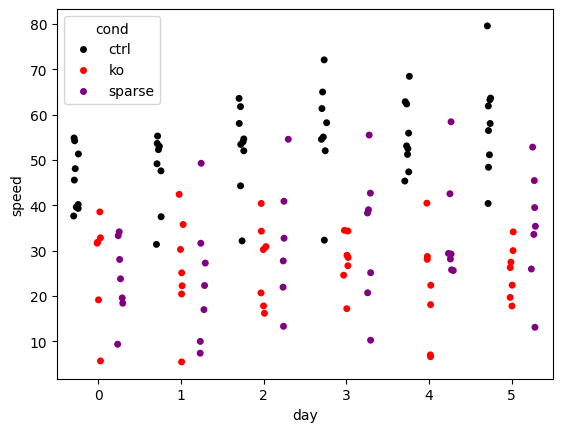

In [45]:
fig, ax = plt.subplots()
tmp_df = df.groupby(['mouse', 'day', 'cond'])['speed'].mean().reset_index()

sns.stripplot(data = tmp_df, 
              x='day',
              y='speed',
              hue='cond',
              hue_order=['ctrl', 'ko', 'sparse'],
              palette=['black','red', 'purple'],
              dodge=True,ax = ax,
              )

In [38]:
print(prev_block_ind, first_block_ind)

12908 15434


In [39]:
print(sess.timeseries['raw_speed'].shape)

(1, 96498)


In [40]:
sess.timeseries['raw_speed'][0,prev_block_ind:first_block_ind]

array([19.77795545, 21.86725123, 25.2094321 , ..., 31.073365  ,
       32.03439691, 28.28807353], shape=(2526,))

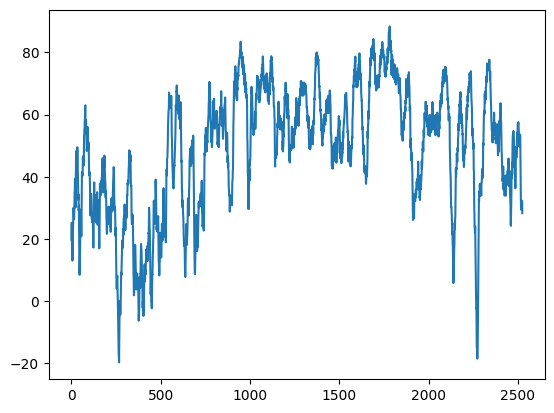

In [41]:
fig, ax = plt.subplots()
ax.plot(inter_block_speed.ravel())

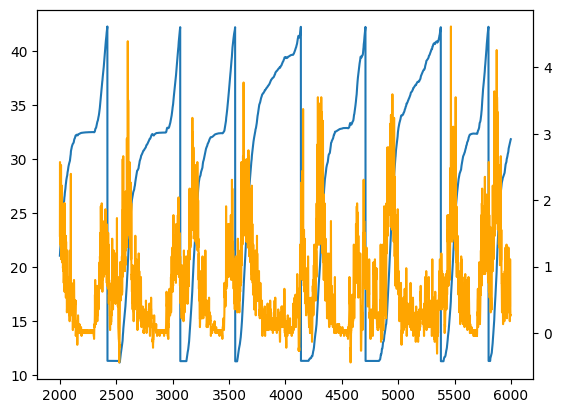

In [20]:
fig, ax = plt.subplots()
# mask = sess.vr_data['t']==-1000
# sess.vr_data.loc[mask]=np.nan
ax.plot(sess.vr_data['t'].iloc[2000:6000])
ax2 = ax.twinx()
ax2.plot(sess.vr_data['dz'].iloc[2000:6000]*10, color='orange')
# ax.plot()
    # ax.scatter(np.diff(sess.vr_data['t']), sess.vr_data['dz'].iloc[1:])

In [21]:
ax.plot()

[]

In [22]:
cov = sp.stats.variation(sess.trial_matrices['speed'][sess.trial_info['LR']==sess.novel_arm, :], axis=0, nan_policy='omit')

In [23]:
print(sess.trial_matrices['speed'][sess.trial_info['LR']==sess.novel_arm, :])

[[48.44829762 58.96922982 65.13895761 ... 51.48602101 41.96866521
  39.50336613]
 [47.125342   50.28849126 53.12306242 ... 49.84080724 46.98017841
  37.67522938]
 [55.47953772 62.68010196 69.96653807 ... 41.21526293 28.35261655
  23.11511208]
 ...
 [41.65698413 53.48944287 71.01161905 ... 44.85555616 45.90334063
  44.38888889]
 [47.86820786 54.44208863 68.83779258 ... 41.48216566 42.3622811
  42.71509434]
 [33.69957376 46.17926249 48.5112705  ... 45.90852232 48.11466911
  43.38136364]]


{'date': '03_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 5}


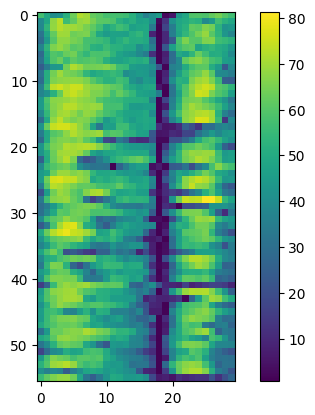

In [58]:
sess = u.load_vr_day(ko_mice[3],5, pkldir = '/mnt/BigDisk/YMaze_VR_Pkls')
fig, ax = plt.subplots()
h = ax.imshow(sess.trial_matrices['speed'][sess.trial_info['LR']!=sess.novel_arm, :])
plt.colorbar(h)


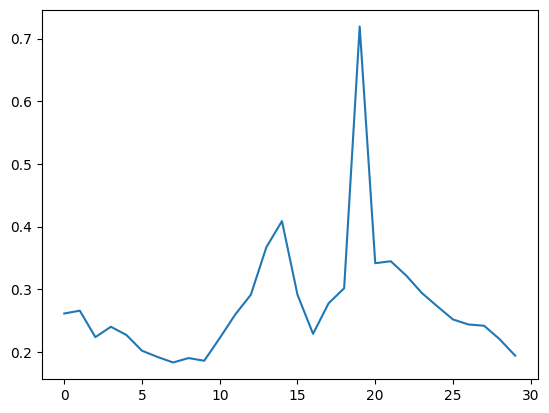

In [25]:
fig, ax = plt.subplots()
ax.plot(cov)

In [14]:
arr = []
for start,stop in zip(sess.trial_start_inds, sess.teleport_inds):
    arr.append([sess.vr_data['time'].iloc[start], sess.vr_data['time'].iloc[stop]])

In [15]:
arr = np.array(arr)
trial_dur = arr[:,1]-arr[:,0]

In [16]:
np.nanmean(sess.trial_matrices['speed'], axis=-1)

array([30.79222655, 42.67597359, 43.95815016, 42.18341347, 47.8627045 ,
       44.70734634, 40.94235415, 45.81801968, 42.27652864, 38.97599484,
       35.70398632, 43.24164229, 42.45657996, 45.47047109, 40.90232533,
       35.82953211, 43.16413324, 42.02520907, 49.43915673, 46.84860443,
       32.4914447 , 36.06454778, 40.25201062, 45.42716491, 36.94312023,
       37.48638764, 40.67305753, 36.17474655, 47.62803206, 47.89081088,
       36.73277553, 41.7404089 , 42.75768373, 45.40818943, 52.56880943,
       42.99352148, 41.06275966, 44.28363954, 46.792711  , 49.99099109,
       35.19791694, 36.9069632 , 41.04548987, 50.70476034, 47.74292669,
       41.63723876, 41.05725819, 56.16433037, 49.40980079, 47.34631266,
       43.51329516, 52.28101089, 53.61916401, 28.76850059, 37.56656143,
       49.30543889, 53.28498178, 43.91747484, 51.65647739, 48.03116446,
       36.820186  , 44.309863  , 51.85668548, 37.77090827, 41.70223585,
       39.27457949, 48.4680276 , 52.82298674, 51.68189857, 48.95

In [18]:
for i in range(trial_dur.shape[0]):
    print(trial_dur[i], 300/np.nanmean(sess.trial_matrices['speed'][i], axis=-1))

13.316010000000006 9.742718652221509
12.065759999999997 7.029716601233743
13.315600000000003 6.824672987812202
12.256650000000008 7.111800001728955
11.139700000000005 6.267928298602143
12.625399999999999 6.71030657229304
14.747500000000002 7.3273754341682285
12.014999999999986 6.547642217435142
9.943999999999988 7.096136075159906
11.881299999999982 7.697045354793911
13.18379999999999 8.402423117317097
11.890199999999993 6.937756849416992
13.173100000000005 7.066042537643491
11.197000000000003 6.597688407310821
11.637000000000029 7.334546326169635
12.750299999999982 8.37298123561148
11.743899999999996 6.950214853106634
13.396500000000003 7.138572457705394
10.942100000000039 6.0680646648457435
9.527499999999975 6.403605905738174
12.872099999999989 9.233199777208853
13.490000000000009 8.318418459456943
12.243899999999996 7.453043845780553
8.690399999999954 6.603978051023861
10.136799999999994 8.120591821481776
12.21210000000002 8.002905024802116
10.485199999999963 7.37589004249594
11.6981